1. Importing libraries

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

2. Loading dataset as dataframe

In [40]:
df = pd.read_csv('../data/Churn_Modelling_f.csv')

3. Counting nulls by column

In [70]:
total_nulls = df.isnull().sum()
total_nulls

RowNumber           0
CustomerId          0
Surname             1
CreditScore         1
Geography          19
Gender              1
Age                77
Tenure              1
Balance             0
NumOfProducts       0
HasCrCard           0
IsActiveMember      0
EstimatedSalary     0
Exited              0
dtype: int64

4. Counting nulls by row

In [114]:
nulls_row = df[df.isnull().sum(axis = 1) > 0]
nulls_rows = nulls_row.isnull().sum(axis = 1)
nulls_rows

9       1
19      1
29      1
39      1
49      1
       ..
9899    1
9929    1
9959    1
9989    1
9999    1
Length: 97, dtype: int64

5. Percentage of nulls by column

In [71]:
null_percentage = (total_nulls / len(df)) * 100
null_percentage

RowNumber          0.00
CustomerId         0.00
Surname            0.01
CreditScore        0.01
Geography          0.19
Gender             0.01
Age                0.77
Tenure             0.01
Balance            0.00
NumOfProducts      0.00
HasCrCard          0.00
IsActiveMember     0.00
EstimatedSalary    0.00
Exited             0.00
dtype: float64

6. Function for reporting

In [77]:
def null_report(dataframe):
    report = pd.DataFrame({'Variable': total_nulls.index,'#_Nulls':total_nulls.values,'%':null_percentage.values})
    report = report[report['#_Nulls'] > 0].sort_values(by = '#_Nulls', ascending=False)
    return report

In [78]:
null_report(df)

,Variable,#_Nulls,%
6,Age,77,0.77
4,Geography,19,0.19
3,CreditScore,1,0.01
2,Surname,1,0.01
5,Gender,1,0.01
7,Tenure,1,0.01


7. Nulls chart by column

In [97]:
def null_chart(report):
    if report.empty:
        print("No nulls to show in a figure")
        return
    
    plt.figure(figsize = (10,6))
    sns.set_style("whitegrid")

    plot = sns.barplot(data = report, x = '#_Nulls', y = 'Variable', palette = 'viridis')
    plt.title('Null distribution by column', fontsize = 14, pad = 20 )
    sns.despine(left = True, bottom = True)
    plt.show()
    

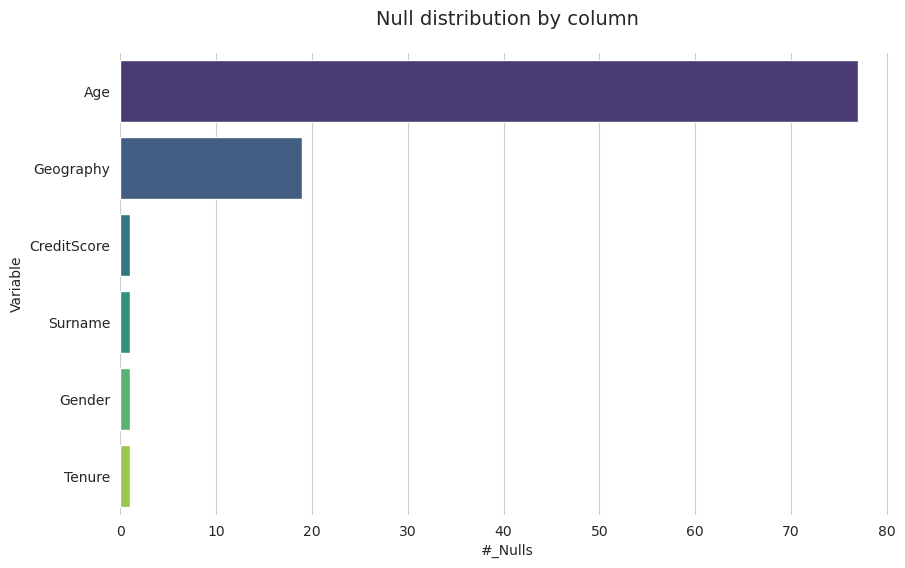

In [98]:
null_chart(null_report(df))

8. Nulls chart by row ocurrence

In [115]:
def nulls_row_chart(nulls_byrow):
    plt.figure(figsize = (10,6))
    sns.set_style("ticks")
    sns.countplot(x = nulls_byrow, palette = 'magma')
    plt.title('Missings by row', fontsize = 14, pad = 20 )
    plt.xlabel('Missing quantities by row')
    plt.ylabel('Rows quantity')
    sns.despine(left = True, bottom = True)
    plt.show()

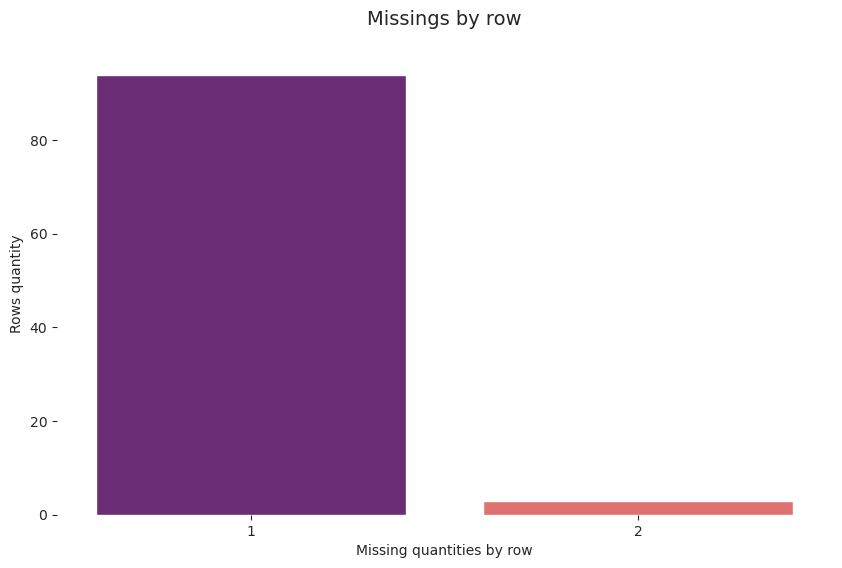

In [116]:
nulls_row_chart(nulls_rows)